In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

np.set_printoptions(suppress=True)

import os
import scanpy as sc
import matplotlib.pyplot as plt

%reload_ext autoreload
%autoreload 2

In [2]:
adata = sc.read_h5ad('../datasets/Weinreb/adata_used.h5ad')
adata

AnnData object with n_obs × n_vars = 44756 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'meta_clones'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'Time_point_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'meta_clones_colors', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
adata.var_names_make_unique()
adata = adata[adata.obs['meta_clones'] != '-1.0', :]
idx_mt = [not gene.startswith('mt-') for gene in adata.var.index]
adata = adata[:, idx_mt]
adata

View of AnnData object with n_obs × n_vars = 44756 × 4995
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'meta_clones'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'Time_point_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'meta_clones_colors', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

### Panel A

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


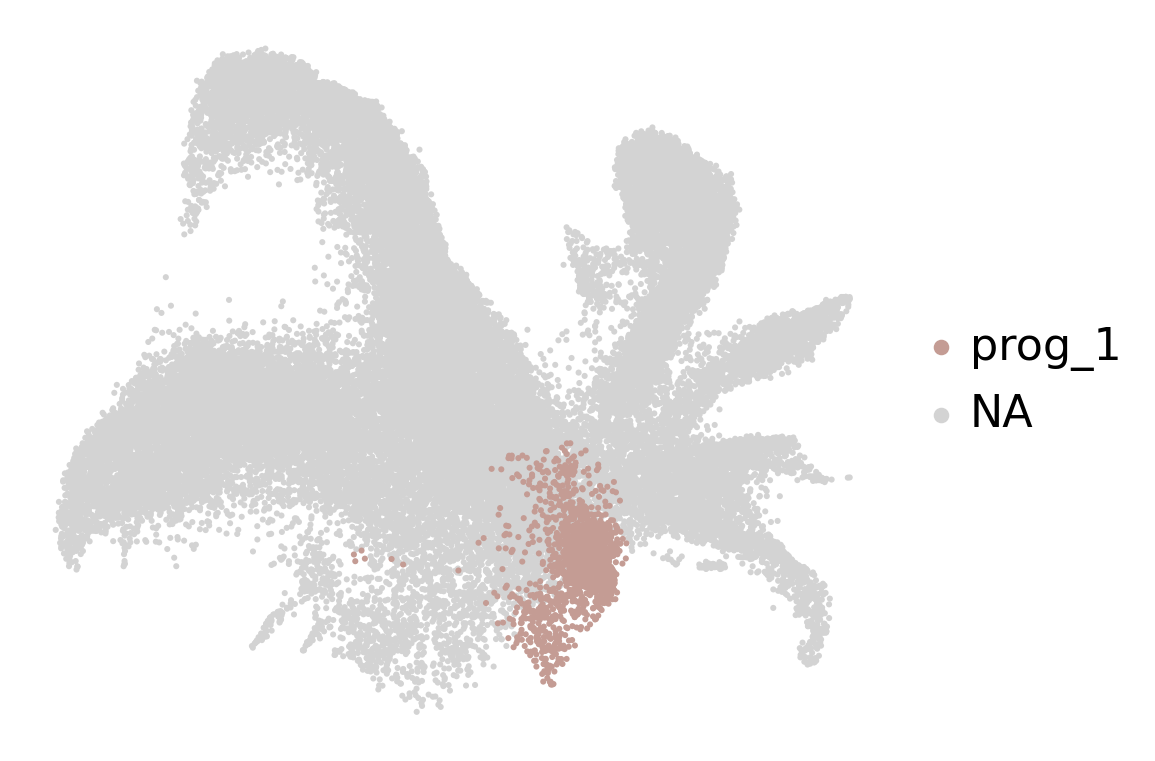

In [4]:
sc.set_figure_params(dpi_save=300, figsize=(7, 6), transparent=True)
sc.pl.umap(
    adata, color=['label_man'], size=30, legend_loc='right margin', groups='prog_1',
    frameon=False, title='', legend_fontsize=20
)

In [6]:
adata_prog1 = adata[adata.obs['label_man'] == 'prog_1', :]

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


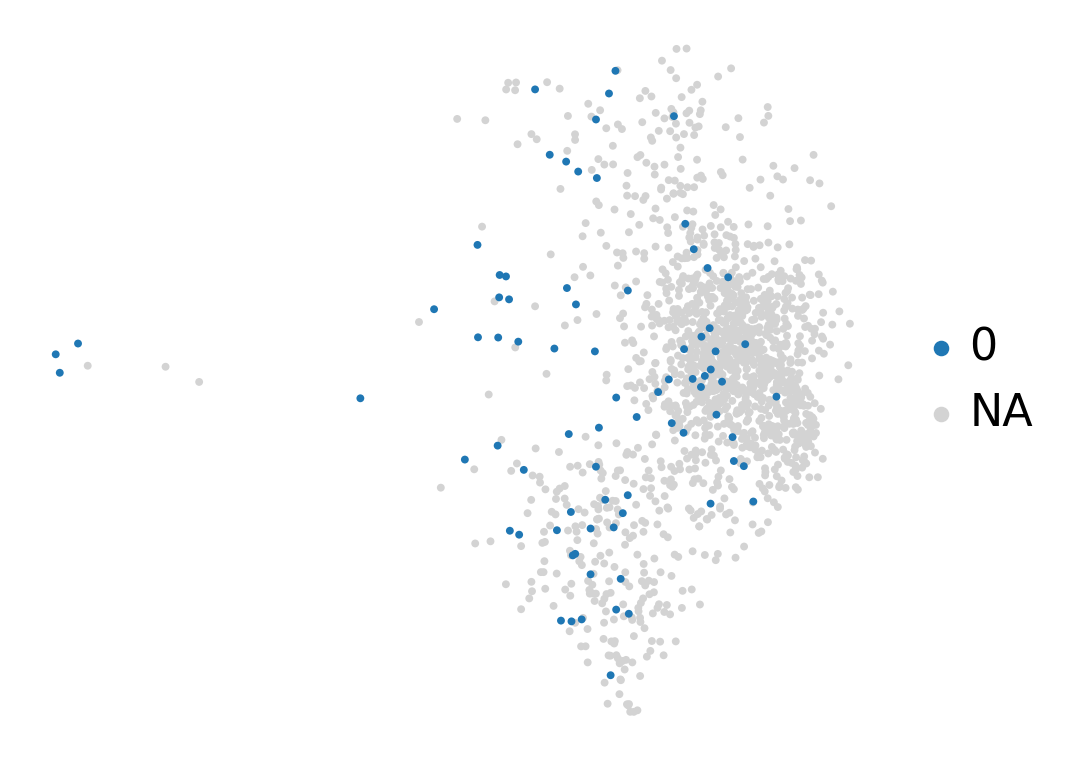

In [7]:
sc.set_figure_params(dpi_save=300, figsize=(7, 6), transparent=True)
sc.pl.umap(
    adata_prog1, color=['meta_clones'], size=50, legend_loc='right margin', groups='0',
    frameon=False, title='', legend_fontsize=20
)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


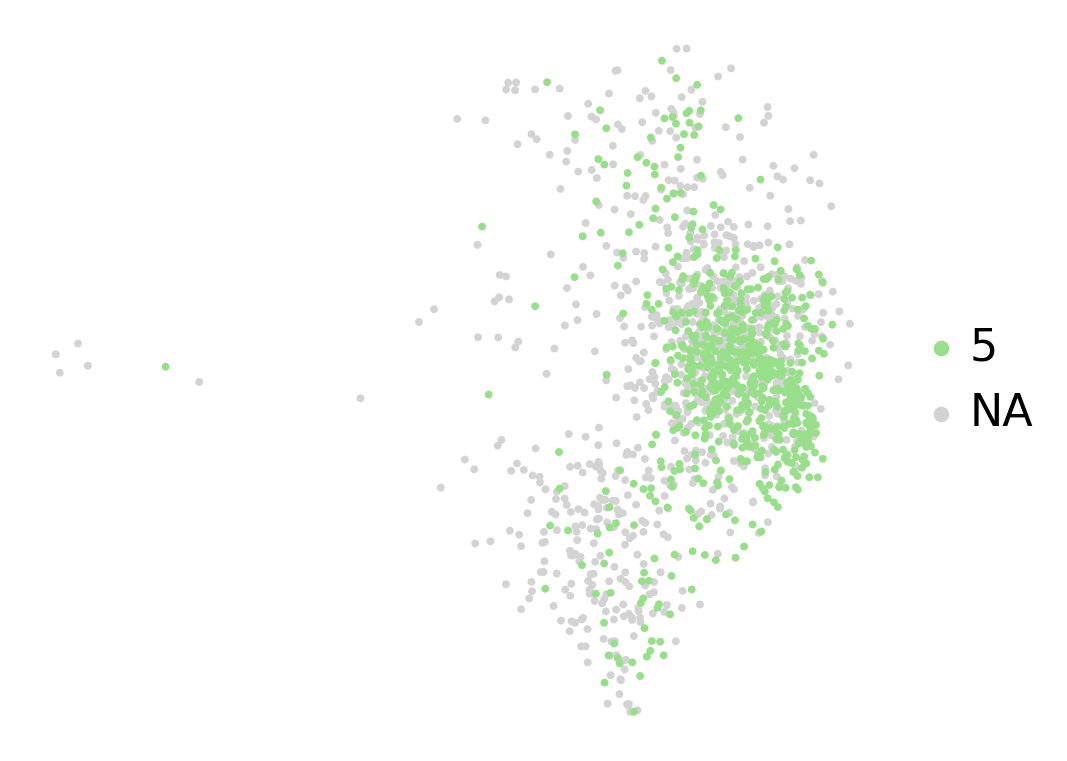

In [8]:
sc.set_figure_params(dpi_save=300, figsize=(7, 6), transparent=True)
sc.pl.umap(
    adata_prog1, color=['meta_clones'], size=50, legend_loc='right margin', groups='5',
    frameon=False, title='', legend_fontsize=20
)

### Panel B

In [9]:
import os 
import torch
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/original//checkpoints/WeinrebDynamicRates/0301_112802/model_last.pt'
model = torch.load(path, map_location='cpu')
device = torch.device('cpu')

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

/tmp/ipykernel_111712/2167669645.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = adata.obs.groupby(['meta_clones', 'label_man']).size().unstack(fill_value=0)


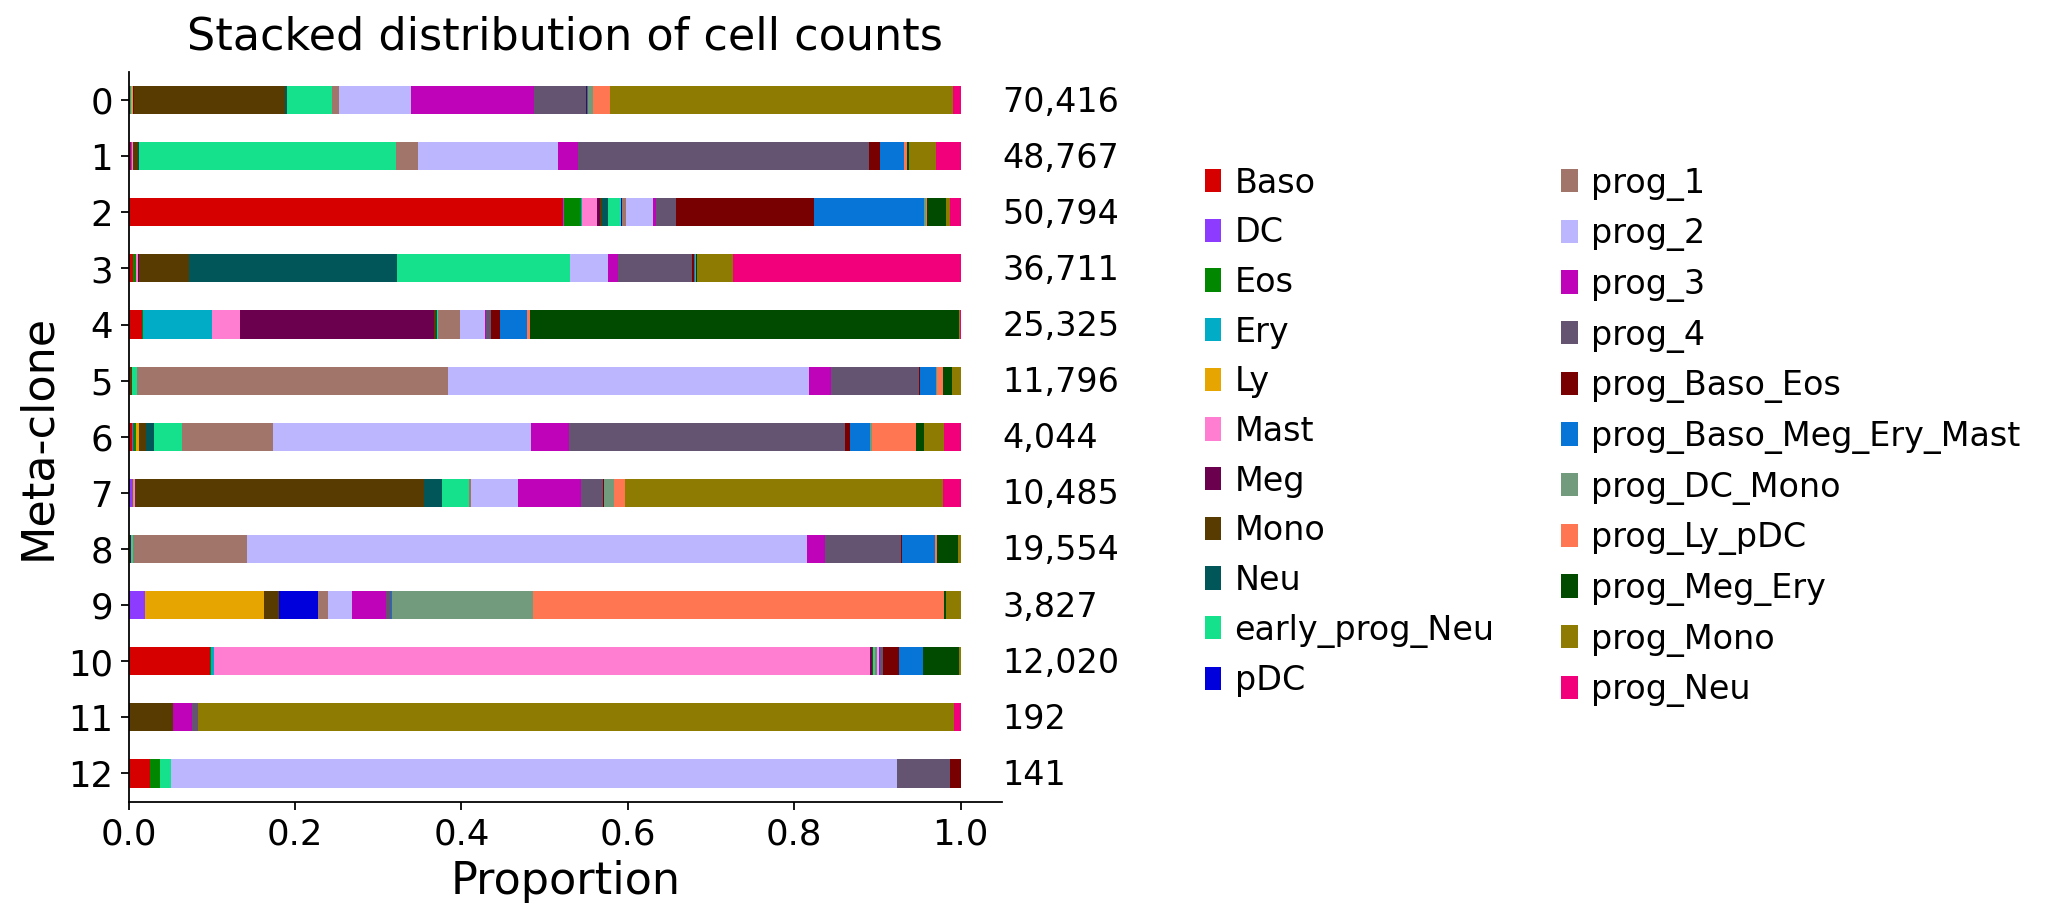

In [15]:
import colorcet as cc
import locale
locale.setlocale(locale.LC_ALL, '')

grouped = adata.obs.groupby(['meta_clones', 'label_man']).size().unstack(fill_value=0)
proportions = grouped.div(grouped.sum(axis=1), axis=0)
legend_labels = proportions.columns

color_palette = sns.color_palette(cc.glasbey_dark, len(legend_labels))
ax = proportions.plot(kind='barh', stacked=True, color=color_palette)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
ax.invert_yaxis()

for idx in range(13):
    formatted_height = locale.format_string("%d", int(model.N[:, :-1, :].sum([0, 2]).numpy()[idx]), grouping=True)
    ax.text(1.05, idx + 0.2, formatted_height, ha='left', rotation=0, fontsize=15)

plt.xlabel('Proportion', fontsize=20)
plt.ylabel('Meta-clone', fontsize=20)
plt.title('Stacked distribution of cell counts', fontsize=20, pad=10)
plt.xticks(rotation=0)
plt.legend(legend_labels, frameon=False, loc='right', ncol=2, fontsize=15,  bbox_to_anchor=(2.2, 0.5))
plt.tick_params(axis='both', which='both', labelsize=16) 

### Panel C

In [16]:
adata = sc.read_h5ad('./datasets/Weinreb/klein_update.h5ad')
adata

AnnData object with n_obs × n_vars = 126861 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'Time_point_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [17]:
adata.var_names_make_unique()
adata = adata[adata.obs['Meta clones'] != '-1.0', :]
idx_mt = [not gene.startswith('mt-') for gene in adata.var.index]
adata = adata[:, idx_mt]
adata

View of AnnData object with n_obs × n_vars = 44756 × 4995
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'Time_point_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [18]:
adata_hsc = adata[adata.obs['label_man'] == 'prog_1', :]
adata_hsc.shape

(1595, 4995)

In [19]:
from collections import Counter
Counter(adata_hsc.obs['label_man'].values)

Counter({'prog_1': 1595})

In [20]:
adata_hsc.obs

,Time_point,Population,Annotation,Well,time_cat,leiden,comb,label_man,clones,Meta clones,group
729,6.0,LK,undiff,2,6.0,15,undiff_15,prog_1,Clone_3292,8,8
827,6.0,LK,undiff,2,6.0,15,undiff_15,prog_1,Clone_3292,8,8
2282,6.0,LK,undiff,2,6.0,15,undiff_15,prog_1,Clone_3292,8,8
2423,6.0,LK,undiff,2,6.0,15,undiff_15,prog_1,Clone_3292,8,8
2432,6.0,LK,undiff,2,6.0,15,undiff_15,prog_1,Clone_5578,8,8
...,...,...,...,...,...,...,...,...,...,...,...
130682,6.0,LSK,undiff,1,6.0,15,undiff_15,prog_1,Clone_2288,5,5
130741,6.0,LSK,undiff,1,6.0,15,undiff_15,prog_1,Clone_1318,5,5
130751,6.0,LSK,undiff,1,6.0,15,undiff_15,prog_1,Clone_2651,5,5
130835,6.0,LSK,undiff,1,6.0,15,undiff_15,prog_1,Clone_4298,5,5


In [21]:
for i in range(13):
    print (f'Meta-Clone {i}:', np.sum(adata_hsc.obs['Meta clones'].values == str(i)))

Meta-Clone 0: 79
Meta-Clone 1: 176
Meta-Clone 2: 41
Meta-Clone 3: 2
Meta-Clone 4: 100
Meta-Clone 5: 689
Meta-Clone 6: 143
Meta-Clone 7: 4
Meta-Clone 8: 348
Meta-Clone 9: 10
Meta-Clone 10: 3
Meta-Clone 11: 0
Meta-Clone 12: 0


In [24]:
del adata_hsc.uns['log1p']

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


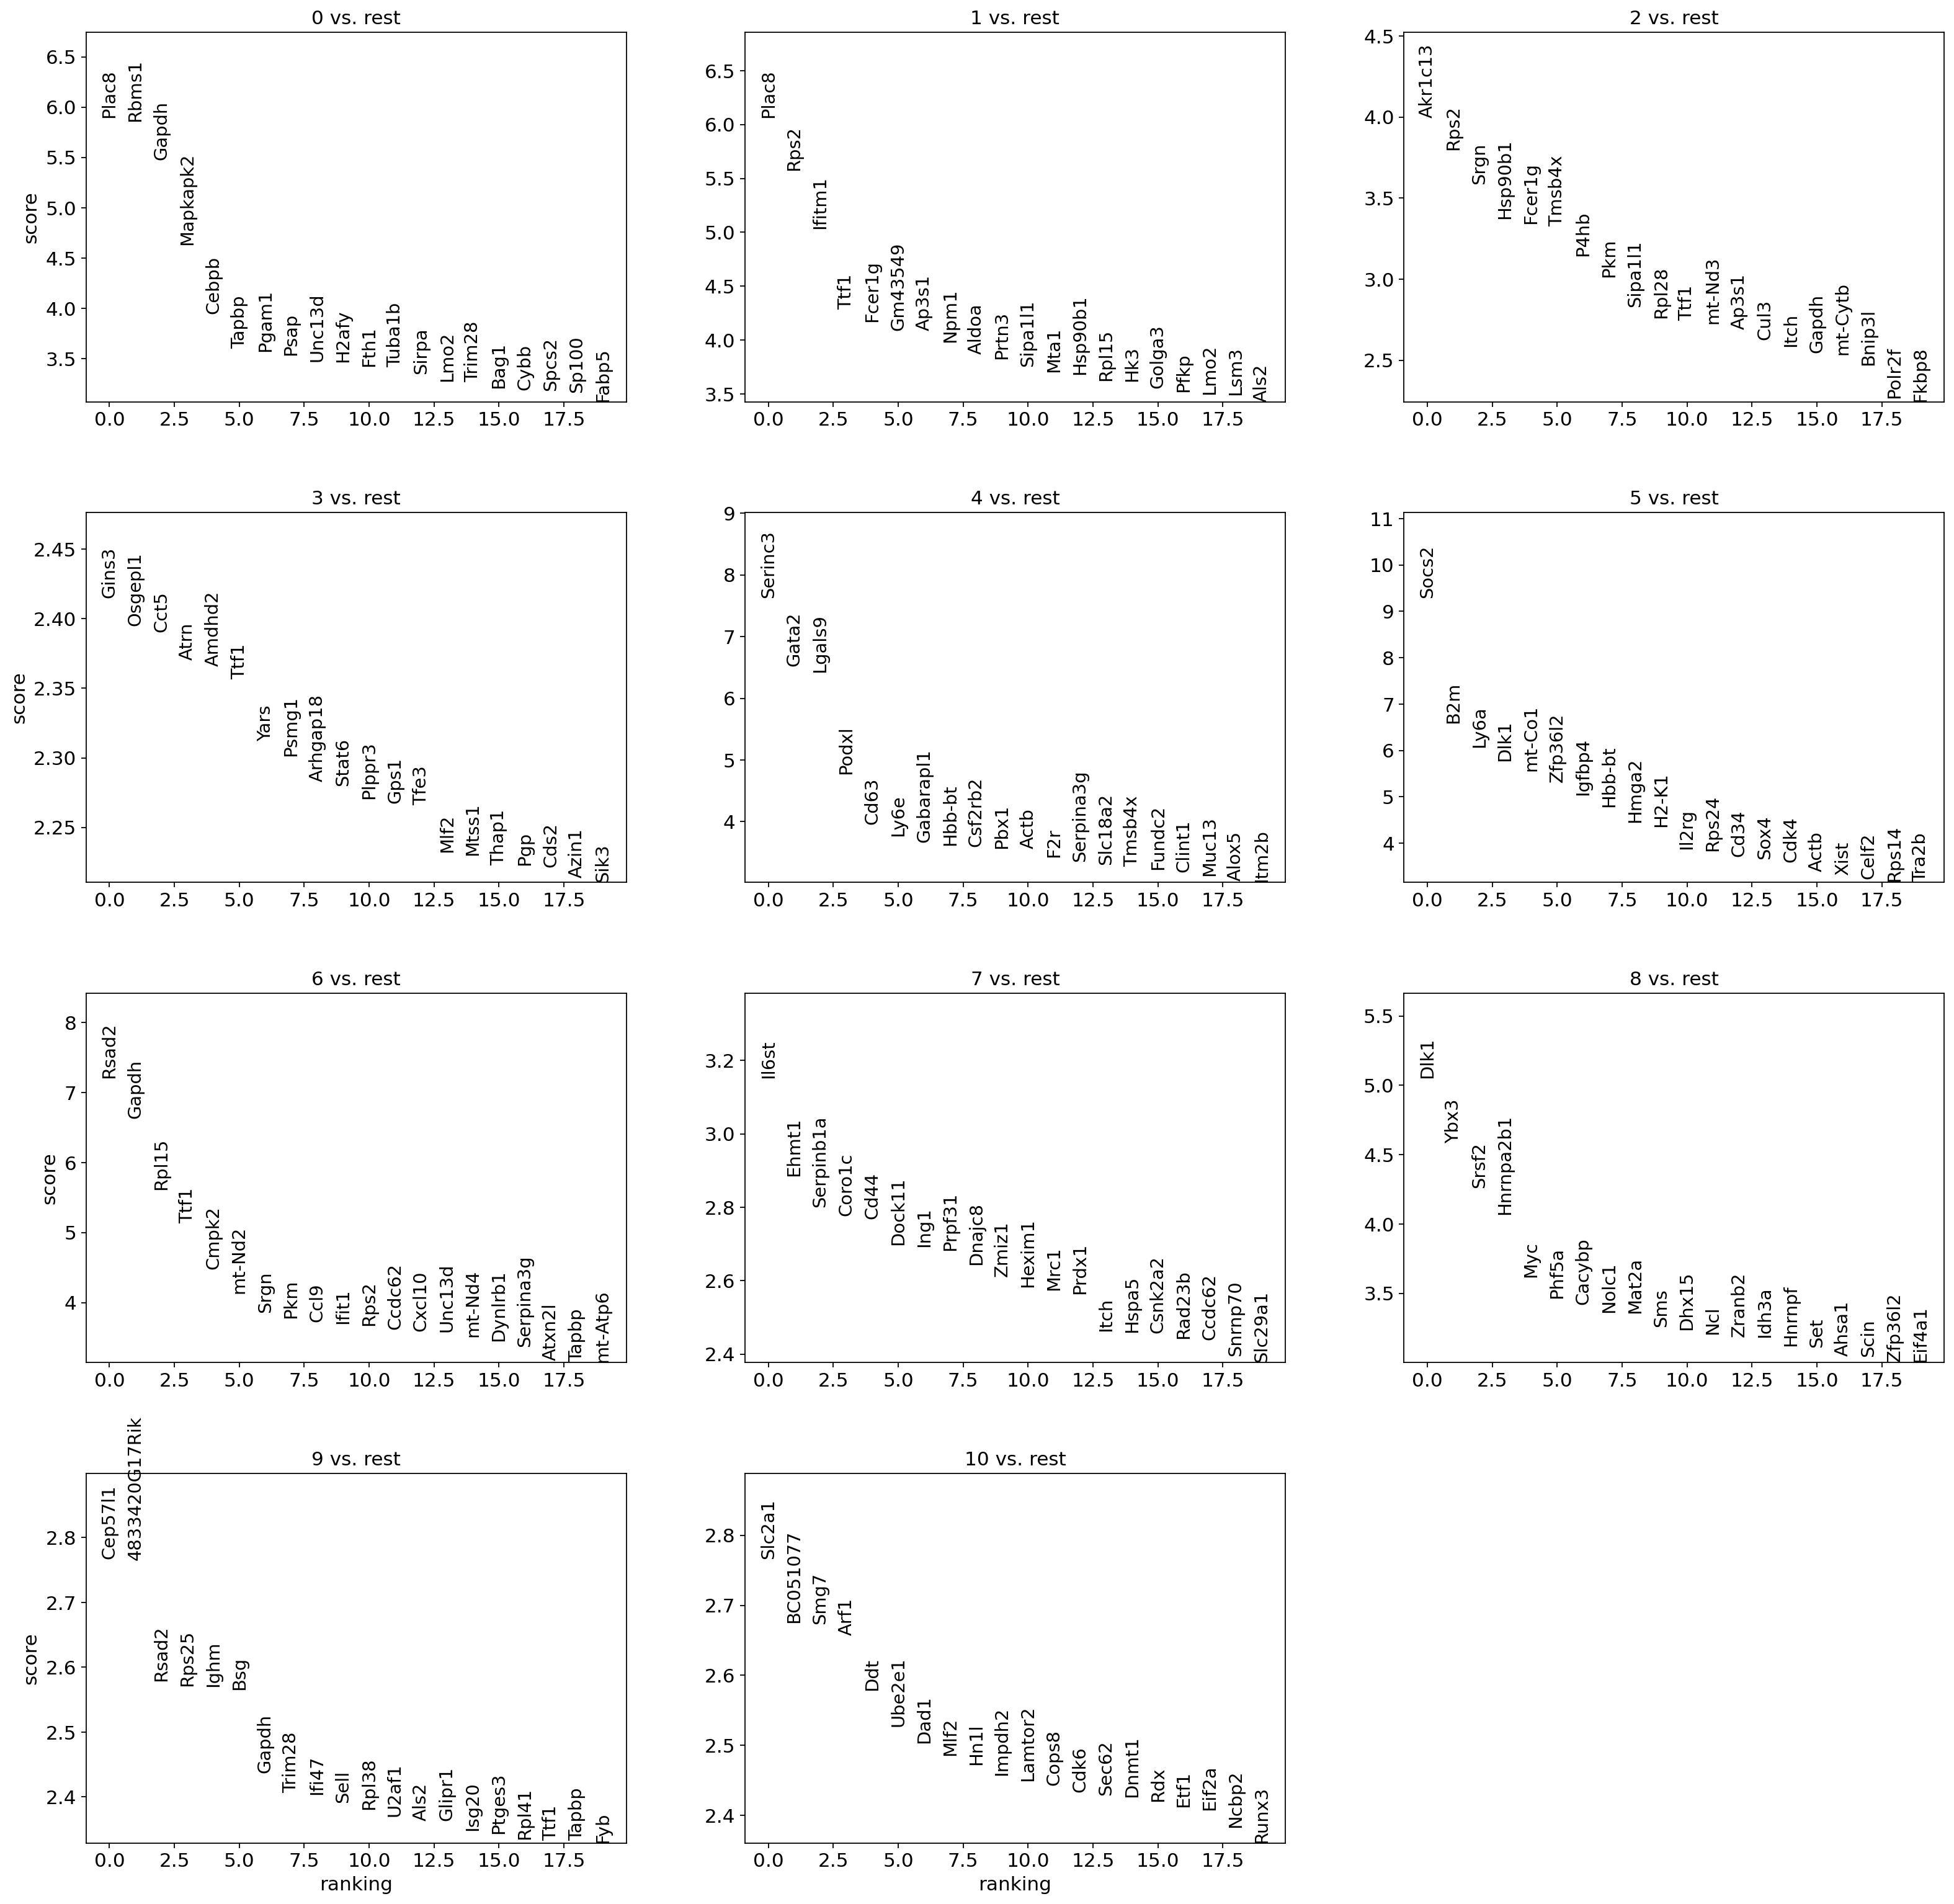

In [25]:
sc.set_figure_params(dpi_save=300, figsize=(8, 6), transparent=True)
plt.rcParams['axes.grid'] = False
sc.tl.rank_genes_groups(adata_hsc, 'Meta clones', method='wilcoxon')
sc.pl.rank_genes_groups(adata_hsc, sharey=False, ncols=3, fontsize=13)

In [26]:
df = pd.DataFrame(adata_hsc.uns['rank_genes_groups']['names'])
df.head(10)

,0,1,2,3,4,5,6,7,8,9,10
0,Plac8,Plac8,Akr1c13,Gins3,Serinc3,Socs2,Rsad2,Il6st,Dlk1,Cep57l1,Slc2a1
1,Rbms1,Rps2,Rps2,Osgepl1,Gata2,B2m,Gapdh,Ehmt1,Ybx3,4833420G17Rik,BC051077
2,Gapdh,Ifitm1,Srgn,Cct5,Lgals9,Ly6a,Rpl15,Serpinb1a,Srsf2,Rsad2,Smg7
3,Mapkapk2,Ttf1,Hsp90b1,Atrn,Podxl,Dlk1,Ttf1,Coro1c,Hnrnpa2b1,Rps25,Arf1
4,Cebpb,Fcer1g,Fcer1g,Amdhd2,Cd63,mt-Co1,Cmpk2,Cd44,Myc,Ighm,Ddt
5,Tapbp,Gm43549,Tmsb4x,Ttf1,Ly6e,Zfp36l2,mt-Nd2,Dock11,Phf5a,Bsg,Ube2e1
6,Pgam1,Ap3s1,P4hb,Yars,Gabarapl1,Igfbp4,Srgn,Ing1,Cacybp,Gapdh,Dad1
7,Psap,Npm1,Pkm,Psmg1,Hbb-bt,Hbb-bt,Pkm,Prpf31,Nolc1,Trim28,Mlf2
8,Unc13d,Aldoa,Sipa1l1,Arhgap18,Csf2rb2,Hmga2,Ccl9,Dnajc8,Mat2a,Ifi47,Hn1l
9,H2afy,Prtn3,Rpl28,Stat6,Pbx1,H2-K1,Ifit1,Zmiz1,Sms,Sell,Impdh2


In [28]:
test = adata_hsc[adata_hsc.obs['Meta clones'].values == str(1), :]
refe = adata_hsc[adata_hsc.obs['Meta clones'].values != str(1), :]

In [29]:
names = ['Hk3', 'Plac8', 'Ctsg', 'Prtn3', 'Ap3s1', 'Ttf1', 'Ifitm1']
for name in names:
    print (np.where(adata_hsc.raw.var.index == name))

(array([12259]),)
(array([18163]),)
(array([5511]),)
(array([18861]),)
(array([2717]),)
(array([23605]),)
(array([12592]),)


/tmp/ipykernel_111712/1020413113.py:8: RuntimeWarning: divide by zero encountered in divide
  fold_change = mean_test / mean_refe
/tmp/ipykernel_111712/1020413113.py:8: RuntimeWarning: invalid value encountered in divide
  fold_change = mean_test / mean_refe
/tmp/ipykernel_111712/1020413113.py:9: RuntimeWarning: divide by zero encountered in log2
  lfc = np.array(np.log2(fold_change)).squeeze()
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/matplotlib/axes/_base.py:2503: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


Text(0.5, 1.0, 'Meta clone #1 vs. Rest')

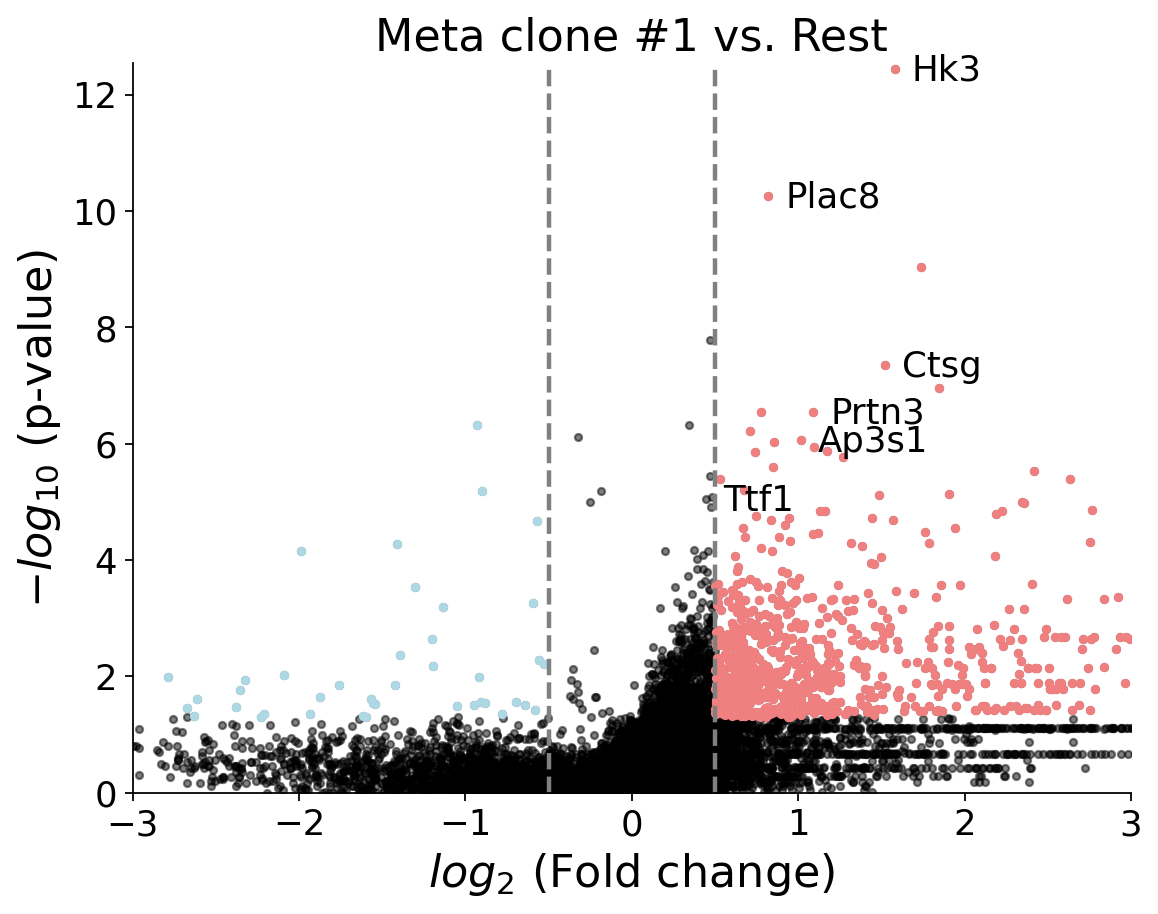

In [30]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

mean_test = np.mean(np.exp(test.raw.X.todense()) - 1, axis=0)
mean_refe = np.mean(np.exp(refe.raw.X.todense()) - 1, axis=0)

fold_change = mean_test / mean_refe
lfc = np.array(np.log2(fold_change)).squeeze()

t_statistic, p_values = stats.mannwhitneyu(test.raw.X.todense(), refe.raw.X.todense())
neg_log_10 = -np.log10(p_values)
threshold = 0.05

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
plt.hlines(y=-np.log10(0.05), linestyles='dashed', xmin=np.nanmin(lfc), xmax=np.nanmax(lfc), color='grey')
plt.scatter(lfc, neg_log_10, color='black', alpha=0.5, s=10)
plt.xlim([-3, 3])
plt.ylim([0, np.nanmax(neg_log_10) + 0.1])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.vlines(x=-0.5, linestyles='dashed', ymin=0, ymax=np.nanmax(neg_log_10), color='grey', linewidth=2)
plt.vlines(x=0.5, linestyles='dashed', ymin=0, ymax=np.nanmax(neg_log_10), color='grey', linewidth=2)
plt.scatter(lfc[np.bitwise_and(lfc > 0.5, p_values < threshold)], neg_log_10[np.bitwise_and(lfc > 0.5, p_values < threshold)], color='lightcoral', s=10)
plt.scatter(lfc[np.bitwise_and(lfc < -0.5, p_values < threshold)], neg_log_10[np.bitwise_and(lfc < -0.5, p_values < threshold)], color='lightblue', s=10)

index = [12259, 18163, 5511, 18861, 2717, 23605]
names = ['Hk3', 'Plac8', 'Ctsg', 'Prtn3', 'Ap3s1', 'Ttf1']
for i in range(len(index)):
    plt.text(lfc[index[i]] + 0.1, neg_log_10[index[i]] - 0.2, names[i], fontsize=16)

axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.grid(False)

plt.xlabel('$log_{2}$ (Fold change)', fontsize=20)
plt.ylabel('$-log_{10}$ (p-value)', fontsize=20)
plt.title('Meta clone #1 vs. Rest', fontsize=20)

### Panel D

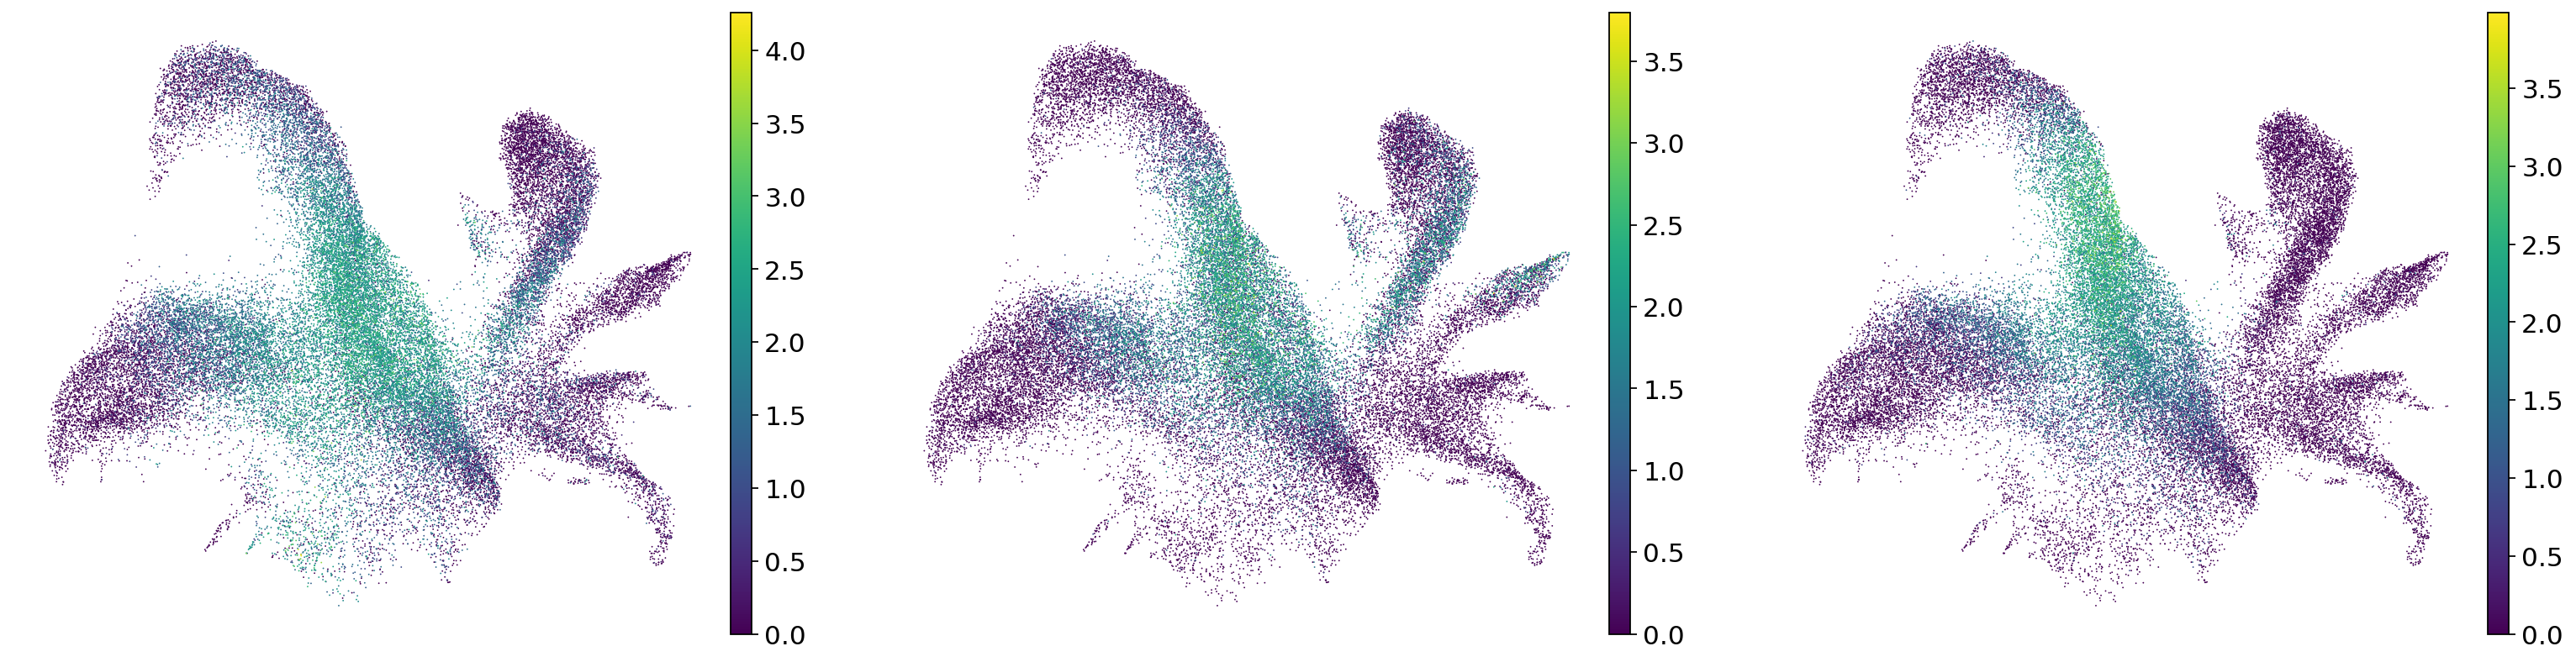

In [31]:
sc.set_figure_params(dpi_save=300, figsize=(7, 6), transparent=True)
sc.pl.umap(adata, color=['Plac8', 'Ctsg', 'Prtn3'], ncols=3, frameon=False, title=['', '', ''])

### Panel E

In [32]:
test = adata_hsc[adata_hsc.obs['Meta clones'].values == str(5), :]
refe = adata_hsc[adata_hsc.obs['Meta clones'].values != str(5), :]

In [33]:
names = ['B2m', 'Ly6a', 'Hbb-bt', 'Dlk1', 'Hmga2', 'Cd34', 'Socs2']
for name in names:
    print (np.where(adata_hsc.raw.var.index == name))

(array([3288]),)
(array([14306]),)
(array([12053]),)
(array([6160]),)
(array([12274]),)
(array([4388]),)
(array([21334]),)


/tmp/ipykernel_111712/2872324762.py:8: RuntimeWarning: divide by zero encountered in divide
  fold_change = mean_test / mean_refe
/tmp/ipykernel_111712/2872324762.py:8: RuntimeWarning: invalid value encountered in divide
  fold_change = mean_test / mean_refe
/tmp/ipykernel_111712/2872324762.py:9: RuntimeWarning: divide by zero encountered in log2
  lfc = np.array(np.log2(fold_change)).squeeze()
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/matplotlib/axes/_base.py:2503: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


Text(0.5, 1.0, 'Meta clone #5 vs. Rest')

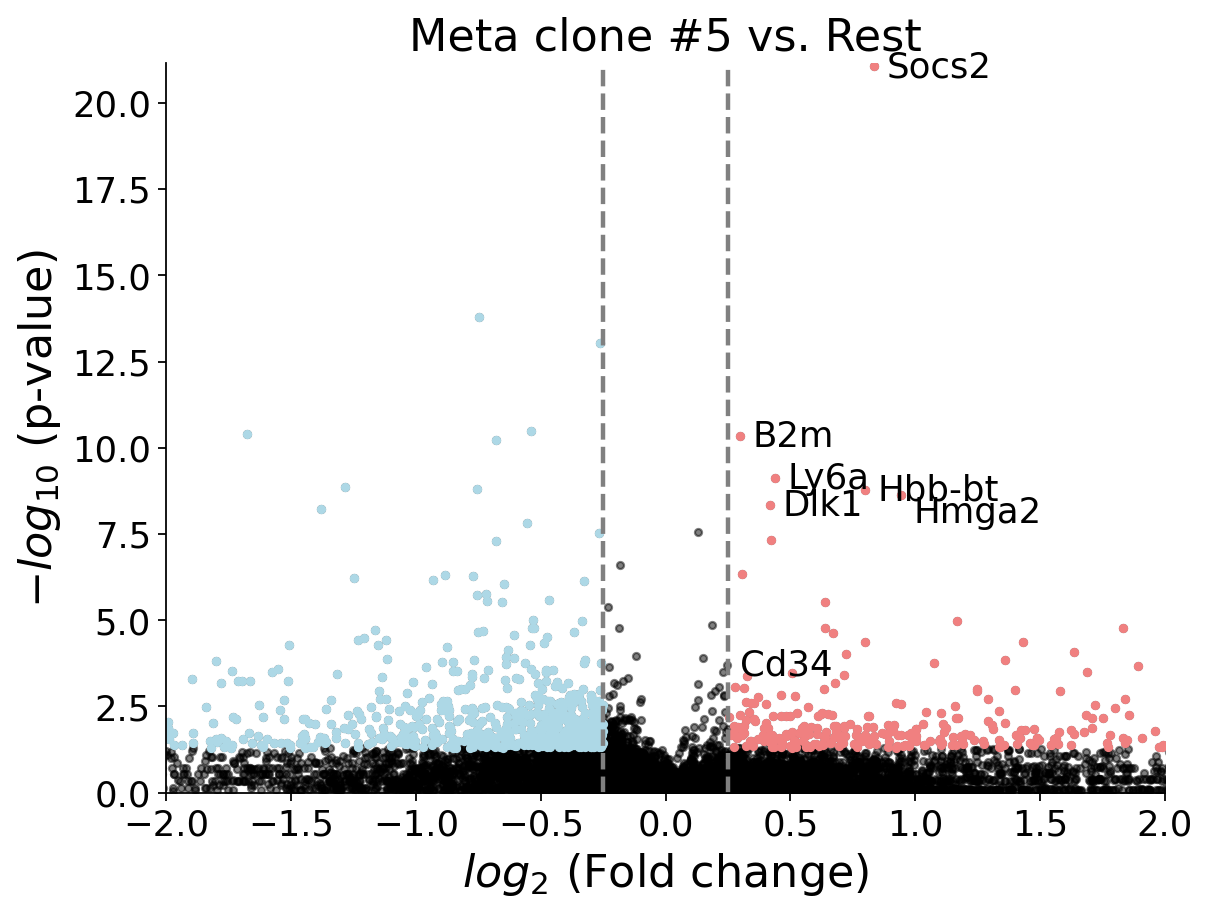

In [34]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

mean_test = np.mean(np.exp(test.raw.X.todense()) - 1, axis=0)
mean_refe = np.mean(np.exp(refe.raw.X.todense()) - 1, axis=0)

fold_change = mean_test / mean_refe
lfc = np.array(np.log2(fold_change)).squeeze()

t_statistic, p_values = stats.mannwhitneyu(test.raw.X.todense(), refe.raw.X.todense())
neg_log_10 = -np.log10(p_values)
threshold = 0.05

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
plt.hlines(y=-np.log10(0.05), linestyles='dashed', xmin=np.nanmin(lfc), xmax=np.nanmax(lfc), color='grey')
plt.scatter(lfc, neg_log_10, color='black', alpha=0.5, s=10)
plt.xlim([-2, 2])
plt.ylim([0, np.nanmax(neg_log_10) + 0.1])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.vlines(x=-0.25, linestyles='dashed', ymin=0, ymax=np.nanmax(neg_log_10), color='grey', linewidth=2)
plt.vlines(x=0.25, linestyles='dashed', ymin=0, ymax=np.nanmax(neg_log_10), color='grey', linewidth=2)
plt.scatter(lfc[np.bitwise_and(lfc > 0.25, p_values < threshold)], neg_log_10[np.bitwise_and(lfc > 0.25, p_values < threshold)], color='lightcoral', s=10)
plt.scatter(lfc[np.bitwise_and(lfc < -0.25, p_values < threshold)], neg_log_10[np.bitwise_and(lfc < -0.25, p_values < threshold)], color='lightblue', s=10)

index = [3288, 14306, 12053, 6160, 4388, 21334]
names = ['B2m', 'Ly6a', 'Hbb-bt', 'Dlk1', 'Cd34', 'Socs2']

for i in range(len(index)):
    plt.text(lfc[index[i]] + 0.05, neg_log_10[index[i]] - 0.3, names[i], fontsize=16)

plt.text(lfc[12274] + 0.05, neg_log_10[12274] - 0.8, 'Hmga2', fontsize=16)

axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.grid(False)

plt.xlabel('$log_{2}$ (Fold change)', fontsize=20)
plt.ylabel('$-log_{10}$ (p-value)', fontsize=20)
plt.title('Meta clone #5 vs. Rest', fontsize=20)

### Panel F

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWa

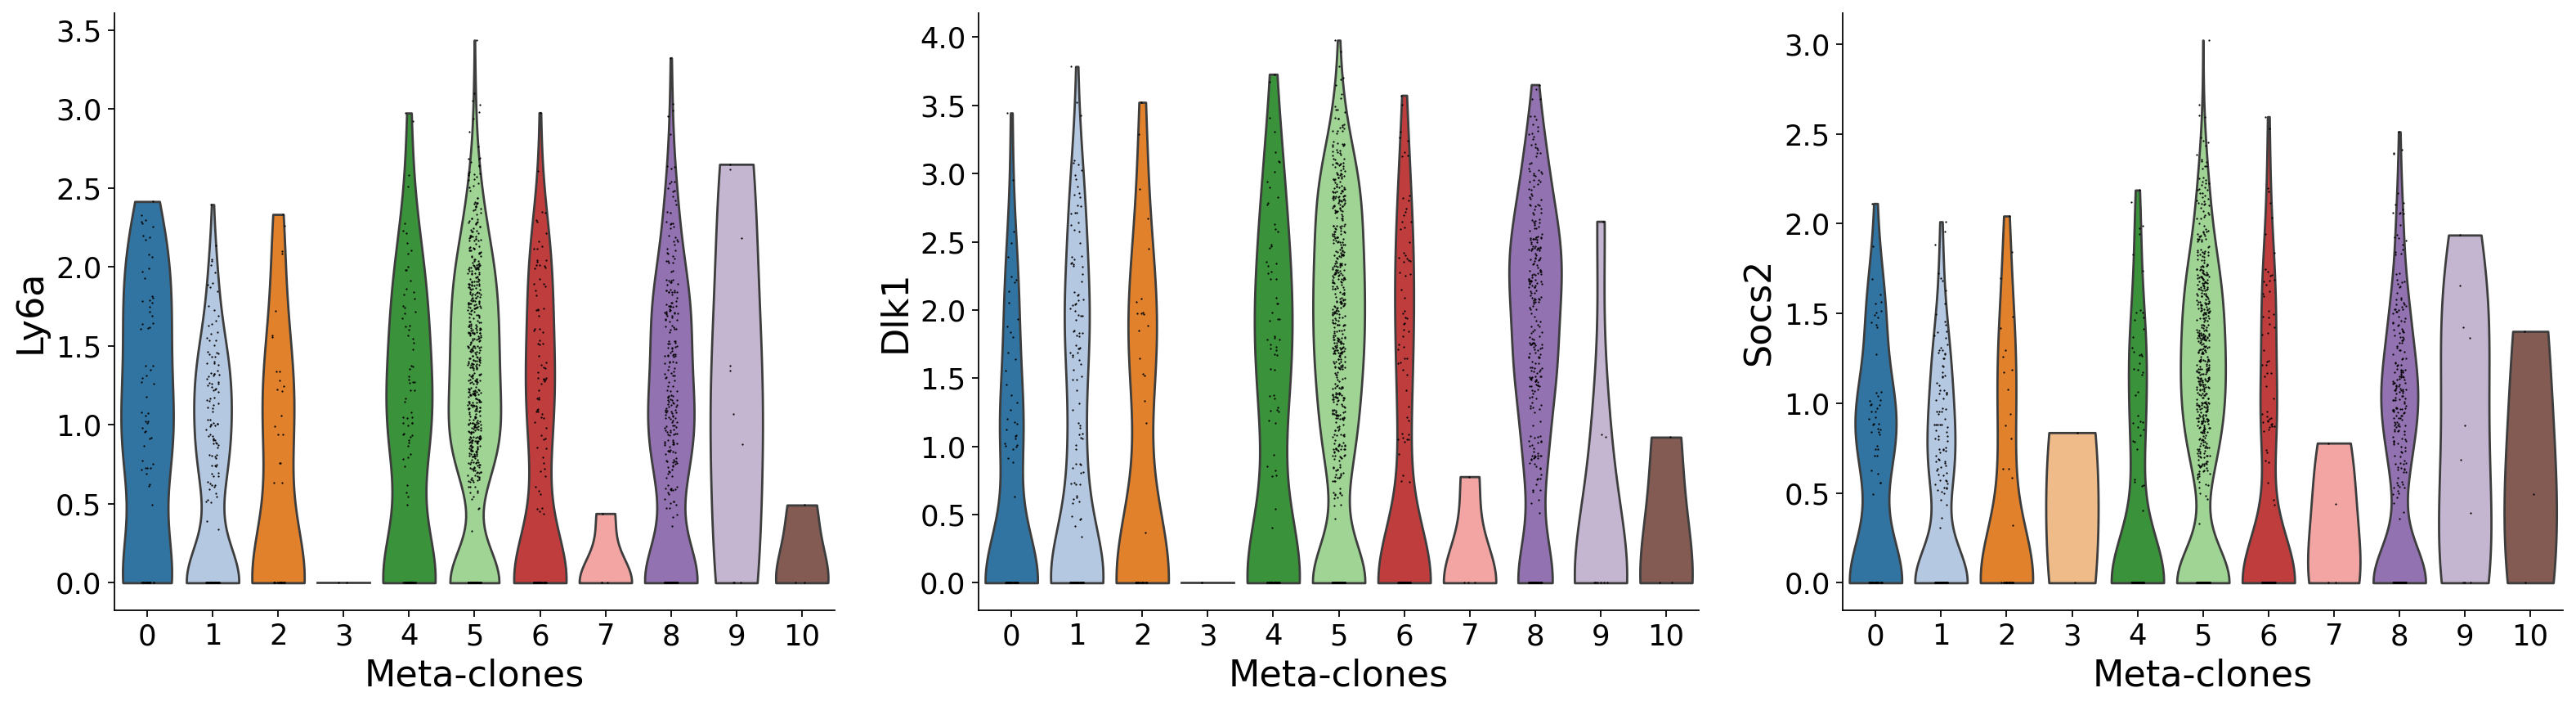

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
sc.set_figure_params(dpi_save=300, figsize=(8, 6))
names = ['Ly6a', 'Dlk1', 'Socs2']

for idx, gene in enumerate(names):
    sc.pl.violin(adata_hsc, gene, groupby='Meta clones', ax=axes[idx], show=False, palette='tab20')
    axes[idx].set_xlabel('Meta-clones')
    axes[idx].yaxis.grid(False)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

    axes[idx].set_xlabel('Meta-clones', fontsize=20)  # Adjust fontsize as needed
    axes[idx].set_ylabel(gene, fontsize=20)  # You can set y-label if needed
    
    # Set tick parameters for x and y axes
    axes[idx].tick_params(axis='x', labelsize=16)  # Adjust x-tick font size
    axes[idx].tick_params(axis='y', labelsize=16)  

### Panel G

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old be

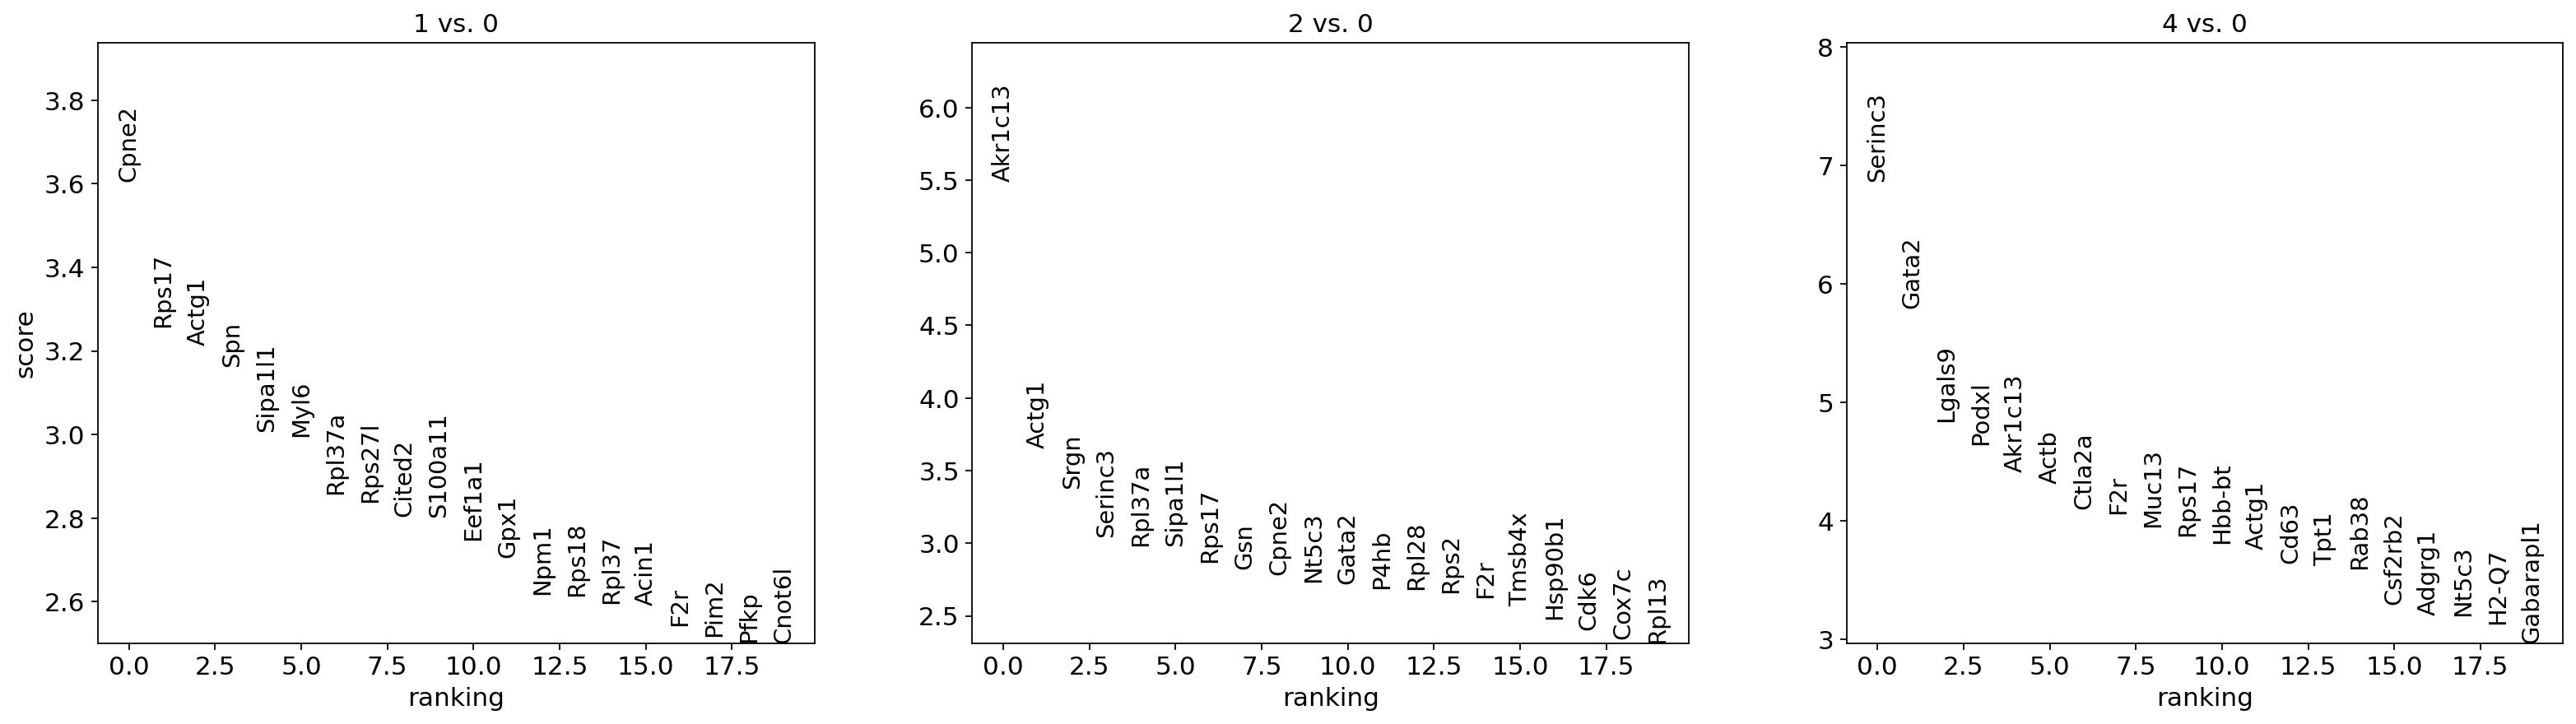

In [36]:
sc.set_figure_params(dpi_save=300, figsize=(8, 6), transparent=True)
plt.rcParams['axes.grid'] = False
sc.tl.rank_genes_groups(adata_hsc, 'Meta clones', method='wilcoxon', groups=['1', '2', '4'], reference='0')
sc.pl.rank_genes_groups(adata_hsc, sharey=False, ncols=3, fontsize=13)

In [37]:
df = pd.DataFrame(adata_hsc.uns['rank_genes_groups']['names'])
df.head(10)

,1,2,4
0,Cpne2,Akr1c13,Serinc3
1,Rps17,Actg1,Gata2
2,Actg1,Srgn,Lgals9
3,Spn,Serinc3,Podxl
4,Sipa1l1,Rpl37a,Akr1c13
5,Myl6,Sipa1l1,Actb
6,Rpl37a,Rps17,Ctla2a
7,Rps27l,Gsn,F2r
8,Cited2,Cpne2,Muc13
9,S100a11,Nt5c3,Rps17


In [39]:
test = adata_hsc[adata_hsc.obs['Meta clones'].values == str(4), :]
refe = adata_hsc[adata_hsc.obs['Meta clones'].values == str(0), :]

/tmp/ipykernel_111712/3163118591.py:8: RuntimeWarning: divide by zero encountered in divide
  fold_change = mean_test / mean_refe
/tmp/ipykernel_111712/3163118591.py:8: RuntimeWarning: invalid value encountered in divide
  fold_change = mean_test / mean_refe
/tmp/ipykernel_111712/3163118591.py:9: RuntimeWarning: divide by zero encountered in log2
  lfc = np.array(np.log2(fold_change)).squeeze()


Text(0.5, 1.0, 'Meta clone #4 vs. Meta clone #0')

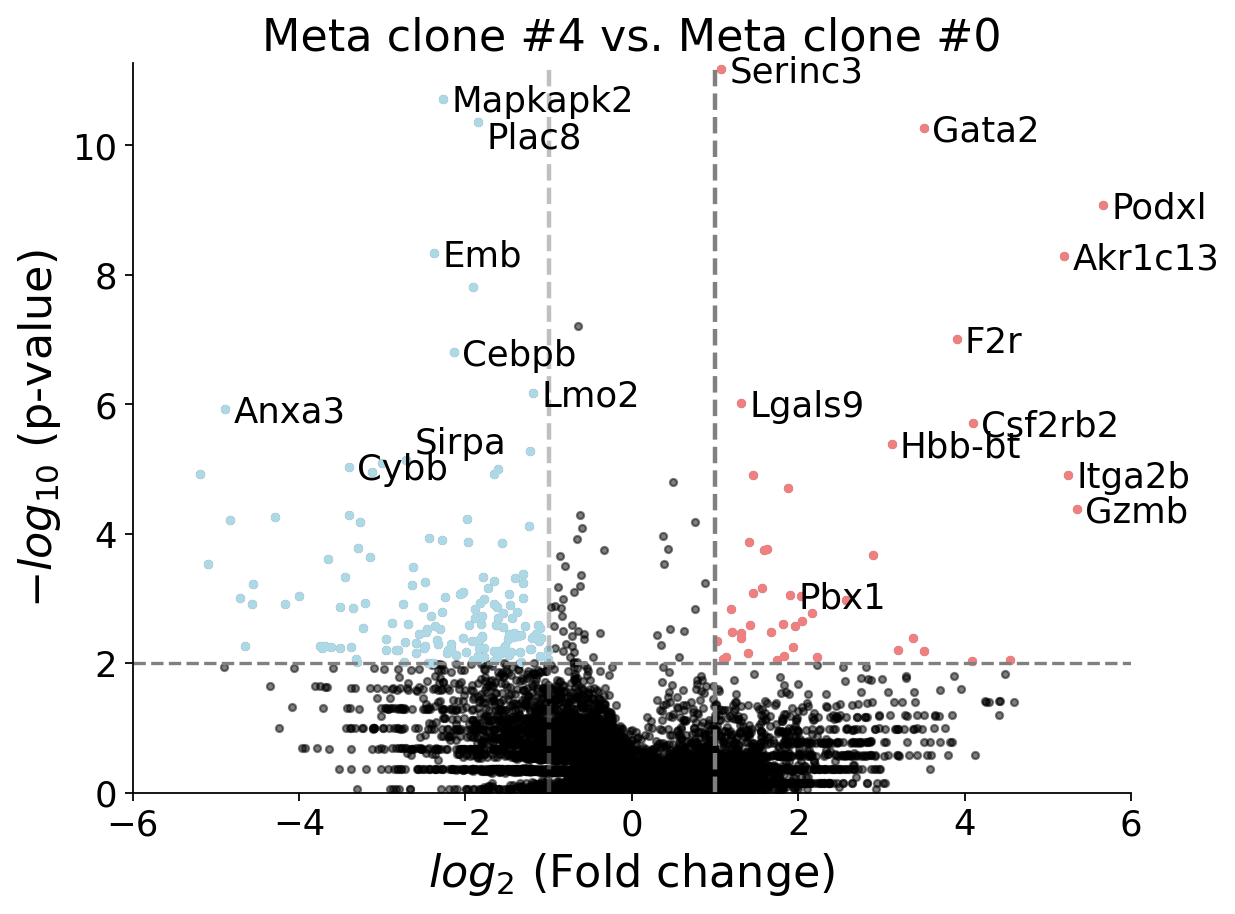

In [40]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

mean_test = np.mean(np.exp(test.raw.X.todense()) - 1, axis=0)
mean_refe = np.mean(np.exp(refe.raw.X.todense()) - 1, axis=0)

fold_change = mean_test / mean_refe
lfc = np.array(np.log2(fold_change)).squeeze()

t_statistic, p_values = stats.mannwhitneyu(test.raw.X.todense(), refe.raw.X.todense())
neg_log_10 = -np.log10(p_values)
threshold = 0.01

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
plt.hlines(y=-np.log10(0.01), linestyles='dashed', xmin=-6, xmax=6, color='grey')
plt.scatter(lfc, neg_log_10, color='black', alpha=0.5, s=10)
plt.xlim([-6, 6])
plt.ylim([0, np.nanmax(neg_log_10) + 0.1])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.vlines(x=-1, linestyles='dashed', ymin=0, ymax=np.nanmax(neg_log_10), color='grey', alpha=0.5, linewidth=2)
plt.vlines(x=1, linestyles='dashed', ymin=0, ymax=np.nanmax(neg_log_10), color='grey', linewidth=2)
plt.scatter(lfc[np.bitwise_and(lfc > 1, p_values < threshold)], neg_log_10[np.bitwise_and(lfc > 1, p_values < threshold)], color='lightcoral', s=10)
plt.scatter(lfc[np.bitwise_and(lfc < -1, p_values < threshold)], neg_log_10[np.bitwise_and(lfc < -1, p_values < threshold)], color='lightblue', s=10)

index = [20399, 7961, 18364, 2431, 7059, 13985, 5409, 12053, 13211, 11933, 17617]
names = ['Serinc3', 'Gata2', 'Podxl', 'Akr1c13', 'F2r', 'Lgals9', 'Csf2rb2', 'Hbb-bt', 'Itga2b', 'Gzmb', 'Pbx1']
for i in range(len(index)):
    plt.text(lfc[index[i]] + 0.1, neg_log_10[index[i]] - 0.2, names[i], fontsize=16)

index = [2683,  4583,  5596,  6768, 14086, 14516]
names = ['Anxa3', 'Cebpb', 'Cybb', 'Emb', 'Lmo2', 'Mapkapk2']
for i in range(len(index)):
    plt.text(lfc[index[i]] + 0.1, neg_log_10[index[i]] - 0.2, names[i], fontsize=16)

plt.text(lfc[20645] + 0.1, neg_log_10[20645] + 0.1, 'Sirpa', fontsize=16)
plt.text(lfc[18163] + 0.1, neg_log_10[18163] - 0.4, 'Plac8', fontsize=16)

axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

plt.xlabel('$log_{2}$ (Fold change)', fontsize=20)
plt.grid(False)
plt.ylabel('$-log_{10}$ (p-value)', fontsize=20)
plt.title('Meta clone #4 vs. Meta clone #0', fontsize=20)

### Panel H

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:325: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:406: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pd.DataFrame(_matrix.stack(dropna=False))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

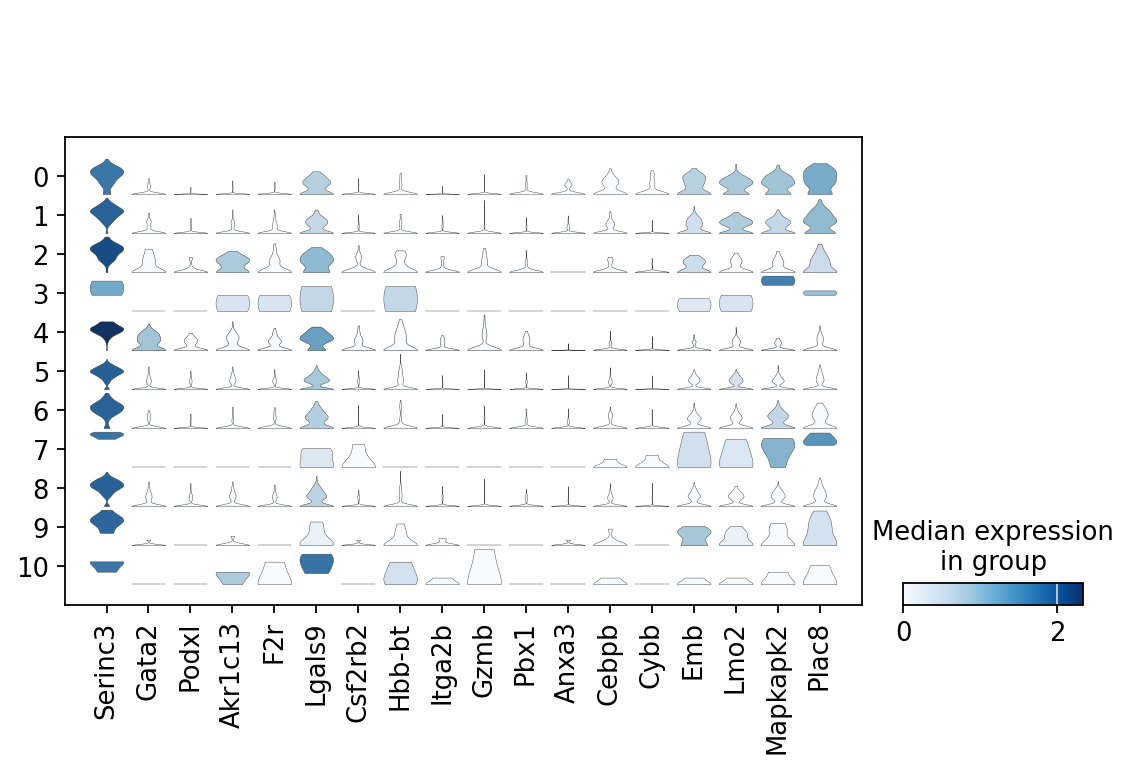

In [41]:
sc.set_figure_params(dpi_save=300, figsize=(16, 6), transparent=True)
sc.pl.stacked_violin(adata_hsc, 
    ['Serinc3', 'Gata2', 'Podxl', 'Akr1c13', 'F2r', 'Lgals9', 'Csf2rb2', 'Hbb-bt', 'Itga2b', 'Gzmb', 'Pbx1', 'Anxa3', 'Cebpb', 'Cybb', 'Emb', 'Lmo2', 'Mapkapk2', 'Plac8'], 
    groupby='Meta clones')

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:325: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:406: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pd.DataFrame(_matrix.stack(dropna=False))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

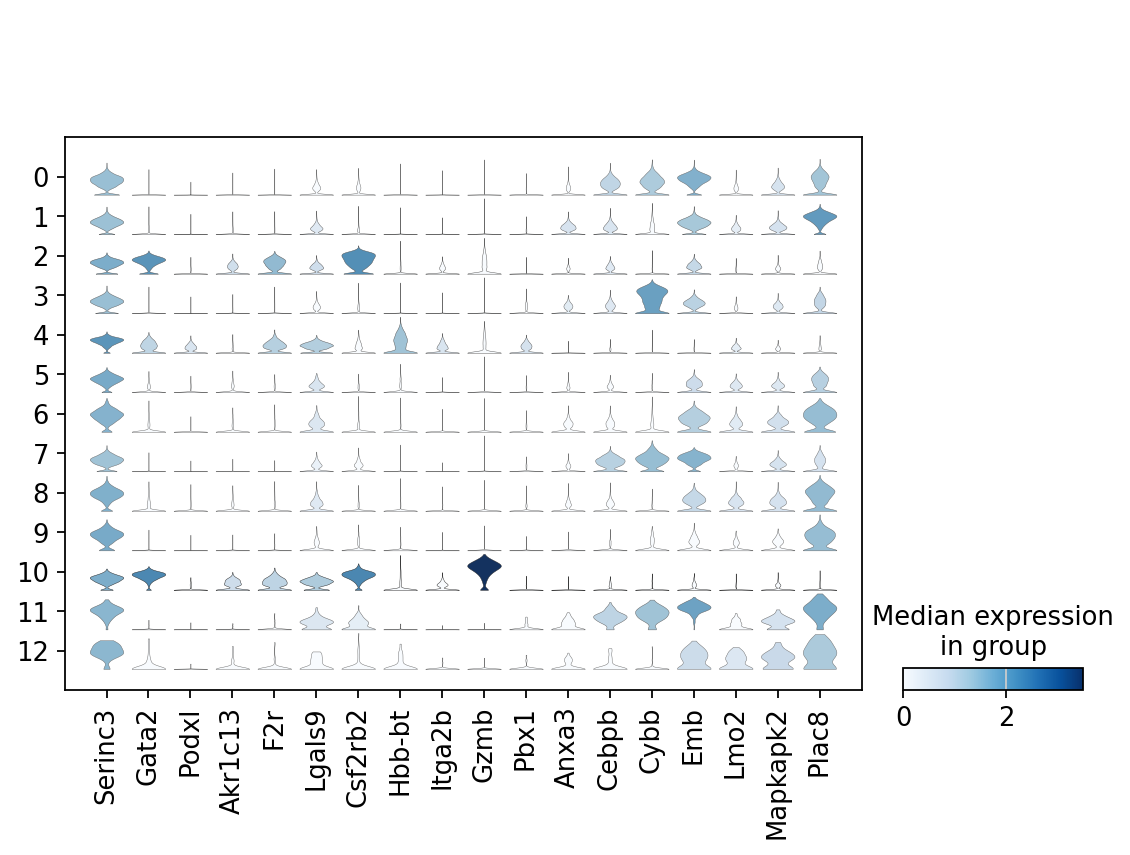

In [42]:
sc.set_figure_params(dpi_save=300, figsize=(16, 6), transparent=True)
sc.pl.stacked_violin(adata, 
    ['Serinc3', 'Gata2', 'Podxl', 'Akr1c13', 'F2r', 'Lgals9', 'Csf2rb2', 'Hbb-bt', 'Itga2b', 'Gzmb', 'Pbx1', 'Anxa3', 'Cebpb', 'Cybb', 'Emb', 'Lmo2', 'Mapkapk2', 'Plac8'], 
    groupby='Meta clones')